# Figure 9 reproduction

This notebook reproduces the Figure 9 setting from `Constrained and Vanishing Expressivity of Quantum Fourier Models` without relying on the missing `logs/*.npy` files used by `Plots/bound.ipynb`.

Setting: `n=4`, Pauli encoding, one encoding layer, global projector observable `O_G = |0><0|`, and local trainable blocks `V` made of five Strongly Entangling layers. The three panels use local block sizes `m=1, 2, 4` with the epsilon values printed in the paper figure.

In [8]:
from __future__ import annotations

import math
from pathlib import Path

import numpy as np

N_QUBITS = 4
D = 2 ** N_QUBITS
SUB_L = 5
M_VALUES = (1, 2, 4)
EPSILONS = {1: 2.26, 2: 0.88, 4: 0.04}

# Increase this to 10000 for a smoother simulation curve closer to the paper plot.
N_SAMPLES = 100
SEED = 20260520

FREQS = np.arange(N_QUBITS + 1)
STEPS = 2 * int(FREQS[-1]) + 1
X_GRID = 2 * np.pi * np.arange(STEPS) / STEPS
OUTPUT_PATH = Path("figure9_reproduction.png")

## Theoretical curves

For Pauli encoding on `n` qubits, the non-negative frequency redundancies are `|R(omega)| = binom(2n, n + omega)`. The blue curve is the global 2-design value from Theorem 1. The pink curve uses the monomial approximate 2-design bound in Eq. (B30), i.e. the Theorem 7 curve shown in the paper figure.

In [9]:
def pauli_redundancies(n_qubits: int) -> np.ndarray:
    """Return non-negative Pauli-encoding redundancies |R(omega)|."""
    degeneracies = np.array([math.comb(n_qubits, k) for k in range(n_qubits + 1)], dtype=float)
    redundancies = []
    for omega in range(n_qubits + 1):
        redundancies.append(float(np.dot(degeneracies[: n_qubits + 1 - omega], degeneracies[omega:])))
    return np.array(redundancies)


def theorem1_global_projector_variance(redundancies: np.ndarray, d: int) -> np.ndarray:
    """Theorem 5 / Eq. (B1) variance for O_G = |0><0|."""
    trace_o = 1.0
    norm2_sq = 1.0
    variances = (
        (d * norm2_sq - trace_o**2)
        / (d * (d**2 - 1))
        * redundancies
        / (d * (d + 1))
    )
    variances[0] += (trace_o**2 - d * norm2_sq) / (d**2 * (d**2 - 1))
    return variances


def theorem7_monomial_bound(redundancies: np.ndarray, d: int, epsilon: float) -> np.ndarray:
    """Formal Theorem 7 / Eq. (B30) monomial approximate 2-design bound."""
    trace_o = 1.0
    norm2_sq = 1.0
    sum_abs_o_tensor_sq = 1.0
    c1 = (d * norm2_sq - trace_o**2) / (d * (d**2 - 1))
    c2 = sum_abs_o_tensor_sq / d**2
    haar = theorem1_global_projector_variance(redundancies, d)
    linear_term = (c1 / d**2 + c2 / (d * (d + 1))) * epsilon * redundancies
    quadratic_term = (c2 / d**2) * (epsilon * redundancies) ** 2
    return haar + linear_term + quadratic_term


REDUNDANCIES = pauli_redundancies(N_QUBITS)
THEOREM1 = theorem1_global_projector_variance(REDUNDANCIES, D)
THEOREM7 = {m: theorem7_monomial_bound(REDUNDANCIES, D, EPSILONS[m]) for m in M_VALUES}

print("freqs:", FREQS)
print("redundancies:", REDUNDANCIES.astype(int))
print("Theorem 1:", np.array2string(THEOREM1, precision=4))

freqs: [0 1 2 3 4]
redundancies: [70 56 28  8  1]
Theorem 1: [9.4615e-04 7.5692e-04 3.7846e-04 1.0813e-04 1.3516e-05]


## NumPy state-vector simulation

The simulation below mirrors the repository implementation: each trainable block draws weights as `2*pi*Normal(0,1)`, applies five Strongly Entangling layers, samples the model on `2*omega_max+1` evenly spaced points, and computes the real FFT coefficients.

In [10]:
I2 = np.eye(2, dtype=complex)


def rz(theta: float) -> np.ndarray:
    return np.array(
        [[np.exp(-0.5j * theta), 0.0], [0.0, np.exp(0.5j * theta)]],
        dtype=complex,
    )


def ry(theta: float) -> np.ndarray:
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)


def rx(theta: float) -> np.ndarray:
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    return np.array([[c, -1j * s], [-1j * s, c]], dtype=complex)


def rot(phi: float, theta: float, omega: float) -> np.ndarray:
    # PennyLane qml.Rot(phi, theta, omega) convention.
    return rz(omega) @ ry(theta) @ rz(phi)


def kron_all(mats: list[np.ndarray]) -> np.ndarray:
    out = np.array([[1.0 + 0.0j]])
    for mat in mats:
        out = np.kron(out, mat)
    return out


def full_single_qubit_gate(gate: np.ndarray, wire: int, n_qubits: int) -> np.ndarray:
    mats = [I2] * n_qubits
    mats[wire] = gate
    return kron_all(mats)


_CNOT_CACHE: dict[tuple[int, int, int], np.ndarray] = {}


def cnot_matrix(n_qubits: int, control: int, target: int) -> np.ndarray:
    key = (n_qubits, control, target)
    if key in _CNOT_CACHE:
        return _CNOT_CACHE[key]
    size = 2**n_qubits
    matrix = np.zeros((size, size), dtype=complex)
    for column in range(size):
        bits = [(column >> (n_qubits - 1 - idx)) & 1 for idx in range(n_qubits)]
        out_bits = bits.copy()
        if bits[control]:
            out_bits[target] ^= 1
        row = 0
        for bit in out_bits:
            row = (row << 1) | bit
        matrix[row, column] = 1.0
    _CNOT_CACHE[key] = matrix
    return matrix


def strongly_entangling_unitary(m_wires: int, rng: np.random.Generator, sub_l: int = SUB_L) -> np.ndarray:
    weights = 2 * np.pi * rng.standard_normal((sub_l, m_wires, 3))
    unitary = np.eye(2**m_wires, dtype=complex)
    for layer in range(sub_l):
        for wire in range(m_wires):
            unitary = full_single_qubit_gate(rot(*weights[layer, wire]), wire, m_wires) @ unitary
        if m_wires > 1:
            gate_range = (layer % (m_wires - 1)) + 1
            for wire in range(m_wires):
                unitary = cnot_matrix(m_wires, wire, (wire + gate_range) % m_wires) @ unitary
    return unitary


def local_trainable_layer(n_qubits: int, m_wires: int, rng: np.random.Generator) -> np.ndarray:
    if n_qubits % m_wires != 0:
        raise ValueError("n_qubits must be divisible by m_wires")
    blocks = [strongly_entangling_unitary(m_wires, rng) for _ in range(n_qubits // m_wires)]
    return kron_all(blocks)


ENCODING_LAYERS = [kron_all([rx(x)] * N_QUBITS) for x in X_GRID]
KET_ZERO = np.zeros(D, dtype=complex)
KET_ZERO[0] = 1.0


def sample_fourier_coefficients(m_wires: int, rng: np.random.Generator) -> np.ndarray:
    v_left = local_trainable_layer(N_QUBITS, m_wires, rng)
    v_right = local_trainable_layer(N_QUBITS, m_wires, rng)
    values = []
    for encoding in ENCODING_LAYERS:
        state = v_right @ (encoding @ (v_left @ KET_ZERO))
        values.append(abs(state[0]) ** 2)
    return np.fft.rfft(np.array(values)) / STEPS


def simulate_variances(m_wires: int, n_samples: int = N_SAMPLES, seed: int = SEED) -> np.ndarray:
    rng = np.random.default_rng(seed + 17 * m_wires)
    coeffs = np.array([sample_fourier_coefficients(m_wires, rng) for _ in range(n_samples)])
    return np.mean(np.abs(coeffs) ** 2, axis=0) - np.abs(np.mean(coeffs, axis=0)) ** 2

In [11]:
SIMULATION = {m: simulate_variances(m) for m in M_VALUES}
for m, values in SIMULATION.items():
    print(f"m={m}:", np.array2string(values, precision=4))

m=1: [2.0593e-03 2.0103e-03 3.0930e-04 2.3003e-05 6.2961e-07]
m=2: [2.6148e-03 1.7427e-03 3.9043e-04 3.7937e-05 5.5738e-06]
m=4: [8.8072e-04 6.5988e-04 4.4284e-04 1.0794e-04 1.3702e-05]


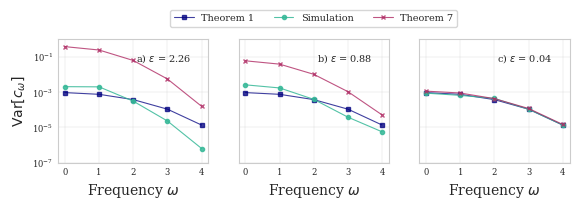

saved to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/figure9_reproduction.png


In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({"font.family": "serif", "font.size": 8})

colors = {
    "theory1": "navy",
    "simulation": "#35b897",
    "theorem7": "#AF2A63",
}
labels = {1: "a", 2: "b", 4: "c"}

fig, axs = plt.subplots(1, 3, figsize=(6.6, 1.6), sharey=True)

for ax, m in zip(axs, M_VALUES):
    ax.plot(FREQS, THEOREM1, marker="s", color=colors["theory1"], label="Theorem 1", markersize=3, linewidth=0.8, alpha=0.75)
    ax.plot(FREQS, SIMULATION[m], marker="o", color=colors["simulation"], label="Simulation", markersize=3, linewidth=0.8, alpha=0.85)
    ax.plot(FREQS, THEOREM7[m], marker="x", color=colors["theorem7"], label="Theorem 7", markersize=3, linewidth=0.8, alpha=0.8)
    ax.set_yscale("log")
    ax.set_xlabel(r"Frequency $\omega$", fontsize=10)
    ax.grid(linewidth=0.3, alpha=0.7)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="both", which="major", labelsize=6, pad=0)
    ax.text(0.52, 0.82, rf"{labels[m]}) $\varepsilon$ = {EPSILONS[m]:.2f}", transform=ax.transAxes, fontsize=7)

axs[0].set_ylabel(r"$\mathrm{Var}[c_\omega]$", fontsize=10)
axs[0].set_ylim(1e-7, 1.0)
axs[1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=3, fontsize=7, frameon=True)

fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"saved to {OUTPUT_PATH.resolve()}")

## New operator-norm bound comparison

The original Figure 9 uses the monomial-norm epsilon values from the paper. The cells below compare that old Theorem 7 bound with the operator-norm bound from `Paper_work/MSQE/main.tex`. Here we use `epsilon_op = {1: 1.0, 2: 1.0, 4: 0.062}`.

The single-coefficient corollary is stated for nonzero frequencies, so the new operator-norm curve is plotted only for `omega > 0`.

In [13]:
OP_NORM_EPSILONS = {1: 1.0, 2: 1.0, 4: 0.062}
OP_NORM_OUTPUT_PATH = Path("figure9_operator_norm_bound_comparison.png")


def operator_norm_single_coefficient_bound(
    var_2design: np.ndarray,
    redundancies: np.ndarray,
    d: int,
    epsilon_op: float,
    observable_frobenius_norm_sq: float = 1.0,
    trace_o: float = 1.0,
) -> np.ndarray:
    """Corollary 9 bound for the aggregated coefficient a_nu."""
    leading_prefactor = ((2 * d - 1) * observable_frobenius_norm_sq - trace_o**2) / (d * (d**2 - 1))
    linear_error = epsilon_op * np.sqrt(redundancies) * leading_prefactor
    higher_order_error = (epsilon_op**2 + epsilon_op**4) * observable_frobenius_norm_sq
    return var_2design + linear_error + higher_order_error


OP_NORM_BOUND = {
    m: operator_norm_single_coefficient_bound(THEOREM1, REDUNDANCIES, D, OP_NORM_EPSILONS[m])
    for m in M_VALUES
}
for m in M_VALUES:
    OP_NORM_BOUND[m] = OP_NORM_BOUND[m].copy()
    OP_NORM_BOUND[m][FREQS == 0] = np.nan


for m in M_VALUES:
    print(f"m={m}, epsilon_op={OP_NORM_EPSILONS[m]}:", np.array2string(OP_NORM_BOUND[m], precision=4))

m=1, epsilon_op=1.0: [   nan 2.0576 2.0406 2.0216 2.0076]
m=2, epsilon_op=1.0: [   nan 2.0576 2.0406 2.0216 2.0076]
m=4, epsilon_op=0.062: [   nan 0.0081 0.0067 0.0053 0.0043]


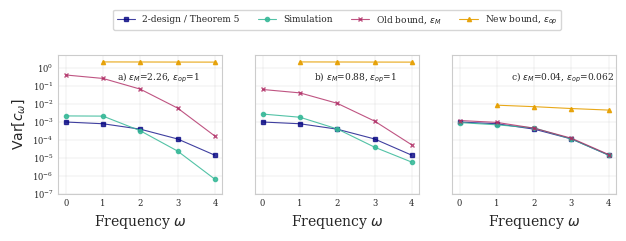

saved to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/figure9_operator_norm_bound_comparison.png


In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({"font.family": "serif", "font.size": 8})

colors = {
    "theory1": "navy",
    "simulation": "#35b897",
    "old_theorem7": "#AF2A63",
    "new_op_bound": "#E69F00",
}
labels = {1: "a", 2: "b", 4: "c"}
nonzero = FREQS > 0

fig, axs = plt.subplots(1, 3, figsize=(7.2, 1.8), sharey=True)

for ax, m in zip(axs, M_VALUES):
    ax.plot(FREQS, THEOREM1, marker="s", color=colors["theory1"], label="2-design / Theorem 5", markersize=3, linewidth=0.8, alpha=0.75)
    ax.plot(FREQS, SIMULATION[m], marker="o", color=colors["simulation"], label="Simulation", markersize=3, linewidth=0.8, alpha=0.85)
    ax.plot(FREQS, THEOREM7[m], marker="x", color=colors["old_theorem7"], label=r"Old bound, $\epsilon_M$", markersize=3, linewidth=0.8, alpha=0.8)
    ax.plot(FREQS[nonzero], OP_NORM_BOUND[m][nonzero], marker="^", color=colors["new_op_bound"], label=r"New bound, $\epsilon_{op}$", markersize=3, linewidth=0.8, alpha=0.9)
    ax.set_yscale("log")
    ax.set_xlabel(r"Frequency $\omega$", fontsize=10)
    ax.grid(linewidth=0.3, alpha=0.7)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="both", which="major", labelsize=6, pad=0)
    ax.text(0.36, 0.82, rf"{labels[m]}) $\epsilon_M$={EPSILONS[m]:.2f}, $\epsilon_{{op}}$={OP_NORM_EPSILONS[m]:.3g}", transform=ax.transAxes, fontsize=6.5)

axs[0].set_ylabel(r"$\mathrm{Var}[c_\omega]$", fontsize=10)
axs[0].set_ylim(1e-7, 5.0)
axs[1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.36), ncol=4, fontsize=6.5, frameon=True)

fig.savefig(OP_NORM_OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"saved to {OP_NORM_OUTPUT_PATH.resolve()}")

Exponential betas: [1, 3, 9, 27]
frequency range: 0 to 40 with 41 non-negative frequencies
redundancy check, total signed pairs = 256 expected 256


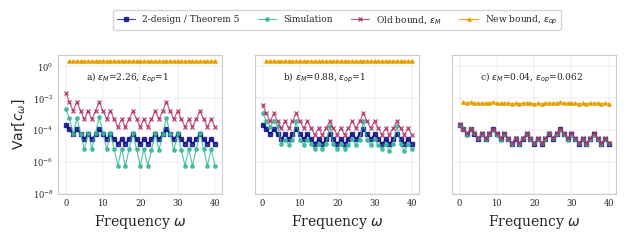

saved to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/figure9_exponential_encoding_bound_comparison.png


In [15]:
# Exponential encoding: beta_k = 3^(k-1), so for n=4 we use beta = [1, 3, 9, 27].
# This cell compares the old monomial-norm Theorem 7 bound with the new operator-norm bound.

EXP_BETAS = 3 ** np.arange(N_QUBITS)
EXP_N_SAMPLES = 1000  # Increase for a smoother simulation curve.
EXP_OUTPUT_PATH = Path("figure9_exponential_encoding_bound_comparison.png")


def weighted_encoding_redundancies(betas):
    """Return non-negative redundancies for one layer of weighted RX encodings."""
    counts = {0: 1}
    for beta in betas:
        beta = int(beta)
        next_counts = {}
        # For one RX(beta*x), the pairwise frequency differences are -beta, 0, +beta,
        # with multiplicities 1, 2, 1 respectively.
        for freq, multiplicity in counts.items():
            for delta, delta_mult in ((-beta, 1), (0, 2), (beta, 1)):
                next_counts[freq + delta] = next_counts.get(freq + delta, 0) + multiplicity * delta_mult
        counts = next_counts
    freqs = np.array(sorted(freq for freq in counts if freq >= 0), dtype=int)
    redundancies = np.array([counts[int(freq)] for freq in freqs], dtype=float)
    return freqs, redundancies


EXP_FREQS, EXP_REDUNDANCIES = weighted_encoding_redundancies(EXP_BETAS)
EXP_THEOREM5 = theorem1_global_projector_variance(EXP_REDUNDANCIES, D)
EXP_OLD_THEOREM7 = {
    m: theorem7_monomial_bound(EXP_REDUNDANCIES, D, EPSILONS[m])
    for m in M_VALUES
}
EXP_OP_BOUND = {
    m: operator_norm_single_coefficient_bound(EXP_THEOREM5, EXP_REDUNDANCIES, D, OP_NORM_EPSILONS[m])
    for m in M_VALUES
}
for m in M_VALUES:
    EXP_OP_BOUND[m] = EXP_OP_BOUND[m].copy()
    EXP_OP_BOUND[m][EXP_FREQS == 0] = np.nan

print("Exponential betas:", EXP_BETAS.tolist())
print("frequency range:", int(EXP_FREQS[0]), "to", int(EXP_FREQS[-1]), "with", len(EXP_FREQS), "non-negative frequencies")
print("redundancy check, total signed pairs =", int(2 * np.sum(EXP_REDUNDANCIES) - EXP_REDUNDANCIES[0]), "expected", D**2)


def exponential_encoding_layers(betas):
    max_freq = int(np.sum(betas))
    steps = 2 * max_freq + 1
    x_grid = 2 * np.pi * np.arange(steps) / steps
    return [kron_all([rx(float(beta) * x) for beta in betas]) for x in x_grid]


EXP_ENCODING_LAYERS = exponential_encoding_layers(EXP_BETAS)
EXP_STEPS = len(EXP_ENCODING_LAYERS)


def sample_exponential_fourier_coefficients(m_wires: int, rng: np.random.Generator) -> np.ndarray:
    v_left = local_trainable_layer(N_QUBITS, m_wires, rng)
    v_right = local_trainable_layer(N_QUBITS, m_wires, rng)
    values = []
    for encoding in EXP_ENCODING_LAYERS:
        state = v_right @ (encoding @ (v_left @ KET_ZERO))
        values.append(abs(state[0]) ** 2)
    return np.fft.rfft(np.array(values)) / EXP_STEPS


def simulate_exponential_variances(m_wires: int, n_samples: int = EXP_N_SAMPLES, seed: int = SEED) -> np.ndarray:
    rng = np.random.default_rng(seed + 1700 + 17 * m_wires)
    coeffs = np.array([sample_exponential_fourier_coefficients(m_wires, rng) for _ in range(n_samples)])
    return np.mean(np.abs(coeffs) ** 2, axis=0) - np.abs(np.mean(coeffs, axis=0)) ** 2


EXP_SIMULATION = {m: simulate_exponential_variances(m) for m in M_VALUES}

plt.rcParams.update({"font.family": "serif", "font.size": 8})
colors = {
    "theory1": "navy",
    "simulation": "#35b897",
    "old_theorem7": "#AF2A63",
    "new_op_bound": "#E69F00",
}
labels = {1: "a", 2: "b", 4: "c"}
nonzero_exp = EXP_FREQS > 0

fig, axs = plt.subplots(1, 3, figsize=(7.2, 1.8), sharey=True)
for ax, m in zip(axs, M_VALUES):
    ax.plot(EXP_FREQS, EXP_THEOREM5, marker="s", color=colors["theory1"], label="2-design / Theorem 5", markersize=2.4, linewidth=0.8, alpha=0.75)
    ax.plot(EXP_FREQS, EXP_SIMULATION[m], marker="o", color=colors["simulation"], label="Simulation", markersize=2.4, linewidth=0.8, alpha=0.85)
    ax.plot(EXP_FREQS, EXP_OLD_THEOREM7[m], marker="x", color=colors["old_theorem7"], label=r"Old bound, $\epsilon_M$", markersize=2.4, linewidth=0.8, alpha=0.8)
    ax.plot(EXP_FREQS[nonzero_exp], EXP_OP_BOUND[m][nonzero_exp], marker="^", color=colors["new_op_bound"], label=r"New bound, $\epsilon_{op}$", markersize=2.4, linewidth=0.8, alpha=0.9)
    ax.set_yscale("log")
    ax.set_xlabel(r"Frequency $\omega$", fontsize=10)
    ax.grid(linewidth=0.3, alpha=0.7)
    ax.tick_params(axis="both", which="major", labelsize=6, pad=0)
    ax.text(0.17, 0.82, rf"{labels[m]}) $\epsilon_M$={EPSILONS[m]:.2f}, $\epsilon_{{op}}$={OP_NORM_EPSILONS[m]:.3g}", transform=ax.transAxes, fontsize=6.5)

axs[0].set_ylabel(r"$\mathrm{Var}[c_\omega]$", fontsize=10)
axs[0].set_ylim(1e-8, 5.0)
axs[1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.36), ncol=4, fontsize=6.5, frameon=True)
fig.savefig(EXP_OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"saved to {EXP_OUTPUT_PATH.resolve()}")

m=4: epsilon_M ~= 0.586072, epsilon_op ~= 0.087385


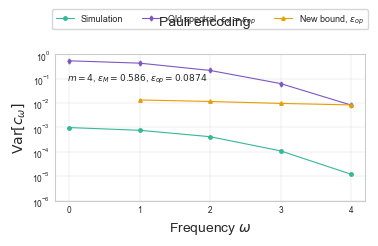

saved to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/auto_pauli_encoding_sub_l_5_bounds.png


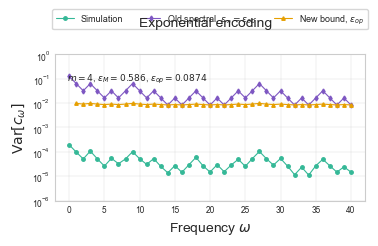

saved to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/auto_exponential_encoding_sub_l_5_bounds.png


{4: {'monomial': 0.5860716520586404, 'op': 0.08738497970293442}}

In [6]:
# Config-driven workflow: estimate both epsilons from the chosen circuit, then plot
# Pauli encoding and exponential encoding bound comparisons.
#
# Example below: one global block m=n_qubits and shallower Strongly Entangling depth SUB_L=2.

import sys
from pathlib import Path

paper_work_dir = Path("Paper_work") if Path("Paper_work").exists() else Path(".")
if str(paper_work_dir.resolve()) not in sys.path:
    sys.path.insert(0, str(paper_work_dir.resolve()))

from auto_encoding_bounds import AutoBoundConfig, run_auto_bound_comparison

AUTO_CONFIG = AutoBoundConfig(
    n_qubits=4,
    sub_l=5,
    m_values=(4,),  # use (1, 2, 4) for all Figure-9 local block sizes, or (4,) for m=n_qubits
    error_samples=500,
    op_iters=15,
    op_restarts=2,
    simulation_samples=1000,
    output_dir=paper_work_dir,
)

AUTO_RESULTS = run_auto_bound_comparison(AUTO_CONFIG)
AUTO_RESULTS["errors"]

# Our experiment

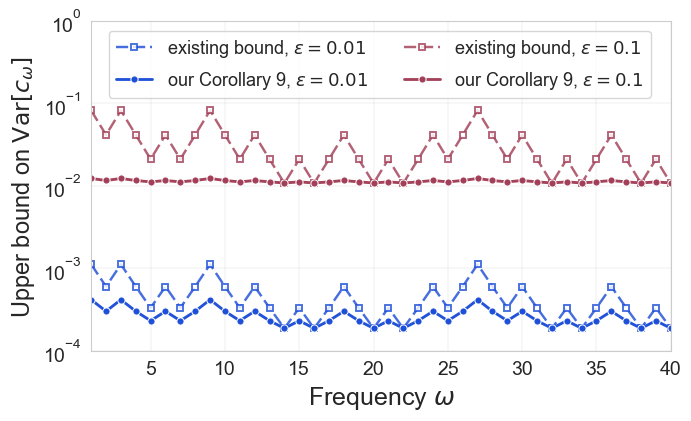

saved to /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/operator_norm_bound_manual_comparison.png


In [65]:
# Pure numerical comparison of operator-norm bounds.
# No circuit simulation and no epsilon estimation are performed here.
# We manually compare epsilon_op = 0.05 and epsilon_op = 0.5.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

MANUAL_EPSILONS_OP = (0.01, 0.1)
MANUAL_OUTPUT_PATH = Path("operator_norm_bound_manual_comparison.png")
MANUAL_N_QUBITS = 4
MANUAL_D = 2 ** MANUAL_N_QUBITS


def manual_weighted_encoding_redundancies(betas):
    counts = {0: 1}
    for beta in betas:
        beta = int(beta)
        next_counts = {}
        for freq, multiplicity in counts.items():
            for delta, delta_mult in ((-beta, 1), (0, 2), (beta, 1)):
                next_counts[freq + delta] = next_counts.get(freq + delta, 0) + multiplicity * delta_mult
        counts = next_counts
    freqs = np.array(sorted(freq for freq in counts if freq > 0), dtype=int)
    redundancies = np.array([counts[int(freq)] for freq in freqs], dtype=float)
    return freqs, redundancies


def manual_theorem5_global_projector_variance(redundancies, d):
    # For nonzero frequencies and O=|0><0|, the delta term in Theorem 5 is absent.
    trace_o = 1.0
    norm2_sq = 1.0
    return (
        (d * norm2_sq - trace_o**2)
        / (d * (d**2 - 1))
        * redundancies
        / (d * (d + 1))
    )


def existing_spectral_bound(var_2design, redundancies, d, epsilon_op):
    # Existing spectral-norm version of Theorem 7, using epsilon_infty = epsilon_op.
    trace_o = 1.0
    norm2_sq = 1.0
    c1 = (d * norm2_sq - trace_o**2) / (d * (d**2 - 1))
    return (
        var_2design
        + (c1 + norm2_sq / (d * (d + 1))) * epsilon_op * np.sqrt(redundancies)
        + norm2_sq * epsilon_op**2 * redundancies
    )


def our_corollary9_bound(var_2design, redundancies, d, epsilon_op):
    # Corollary 9 aggregated-coefficient bound for O=|0><0|.
    trace_o = 1.0
    frobenius_norm_sq = 1.0
    leading_prefactor = ((2 * d - 1) * frobenius_norm_sq - trace_o**2) / (d * (d**2 - 1))
    return (
        var_2design
        + epsilon_op * np.sqrt(redundancies) * leading_prefactor
        + (epsilon_op**2 + epsilon_op**4) * frobenius_norm_sq
    )


ENCODING_NAME = ""
ENCODING_BETAS = 3 ** np.arange(MANUAL_N_QUBITS)

epsilon_colors = ["#1D4ED8", "#A23E57", "#16A34A", "#DC2626", "#7C3AED", "#0891B2"]

def line_style(bound_type, epsilon_index):
    # Works for any manually chosen epsilon values; colors cycle if more than six are used.
    color = epsilon_colors[epsilon_index % len(epsilon_colors)]
    if bound_type == "existing":
        return dict(color=color, linestyle=(0, (5, 2)), marker="s", markerfacecolor="white", markeredgecolor=color, markeredgewidth=1.35, alpha=0.82)
    if bound_type == "ours":
        return dict(color=color, linestyle="-", marker="o", markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.75, alpha=0.98)
    raise ValueError(bound_type)

fig, ax = plt.subplots(1, 1, figsize=(6.8, 4.1), constrained_layout=True)

freqs, redundancies = manual_weighted_encoding_redundancies(ENCODING_BETAS)
var_2design = manual_theorem5_global_projector_variance(redundancies, MANUAL_D)

visible_values = []
for epsilon_index, epsilon_op in enumerate(MANUAL_EPSILONS_OP):
    existing = existing_spectral_bound(var_2design, redundancies, MANUAL_D, epsilon_op)
    ours = our_corollary9_bound(var_2design, redundancies, MANUAL_D, epsilon_op)
    visible_values.extend([existing, ours])

    ax.plot(
        freqs,
        existing,
        label=rf"existing bound, $\epsilon={epsilon_op}$",
        markersize=5.0,
        linewidth=1.75,
        **line_style("existing", epsilon_index),
    )
    ax.plot(
        freqs,
        ours,
        label=rf"our Corollary 9, $\epsilon={epsilon_op}$",
        markersize=5.2,
        linewidth=2.05,
        **line_style("ours", epsilon_index),
    )

y_values = np.concatenate(visible_values)
y_values = y_values[np.isfinite(y_values) & (y_values > 0)]
y_min = 10 ** np.floor(np.log10(np.min(y_values)) - 0.15)
y_max = 10 ** np.ceil(np.log10(np.max(y_values)) + 0.45)
# y_max = max(10.0, 10 ** np.ceil(np.log10(np.max(y_values)) + 0.45))


ax.set_title(ENCODING_NAME, fontsize=25, pad=15)
ax.set_yscale("log")
ax.set_ylim(y_min, y_max)
ax.set_xlim(left=1, right=int(freqs[-1]))
ax.set_xlabel(r"Frequency $\omega$", fontsize=18)
ax.set_ylabel(r"Upper bound on $\mathrm{Var}[c_\omega]$", fontsize=17)
ax.grid(linewidth=0.35, alpha=0.65)
ax.tick_params(axis="both", which="major", labelsize=14)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.55, 0.96), ncol=2, fontsize=13, frameon=True)
fig.savefig(MANUAL_OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"saved to {MANUAL_OUTPUT_PATH.resolve()}")